# Supply Chain & Logistics Performance Analysis of Olist E-commerce Dataset

## Objective

The objective of this project is to analyze supply chain and logistics performance 
using the Olist e-commerce dataset. The project includes data cleaning, exploratory 
data analysis, SQL-based KPI evaluation, and visualization using Power BI. 
Additionally, a machine learning model is developed to predict delivery time 
and improve logistics efficiency.

### Import Required Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Datasets

In [5]:
orders = pd.read_csv("../data/olist_orders.csv")
customers = pd.read_csv("../data/olist_customers.csv")
items = pd.read_csv("../data/olist_order_items.csv")

### Dataset Description

The dataset consists of Olist e-commerce order data from Brazil, including 
customer information, order details, and item-level transactions.

# Initial Data Inspection and Preparation : 


In [6]:
print("Overview of Orders DataSet : ")

orders.head()

Overview of Orders DataSet : 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
print("Overview of customers dataset : ")
customers.head()

Overview of customers dataset : 


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
print("Overview of order_items dataset : ")
items.head()

Overview of order_items dataset : 


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## Dataset Structure and Data Types

In [9]:
print("Orders Dataset Info:\n")
orders.info()

print("\nCustomers Dataset Info:\n")
customers.info()

print("\nOrder Items Dataset Info:\n")
items.info()

Orders Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Customers Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  -----

## Exploratory Data Inspection:

#### Orders Dataset Analysis

In [10]:
# Unique values (order status)
print(orders['order_status'].value_counts())

# Date range
print("-"*50)
print(orders['order_purchase_timestamp'].min())
print(orders['order_purchase_timestamp'].max())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
--------------------------------------------------
2016-09-04 21:15:19
2018-10-17 17:30:18


#### Customers Dataset Analysis

In [11]:
# Unique states
print(customers['customer_state'].value_counts())
print("-"*50)
# Unique cities count
print(customers['customer_city'].nunique())

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64
--------------------------------------------------
4119


#### Order Items Dataset Analysis

In [12]:
# Basic statistics
print(items[['price', 'freight_value']].describe())

print("-"*50)

# Unique products count
print(items['product_id'].nunique())

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000
--------------------------------------------------
32951


**Initial exploratory inspection was performed to understand the structure, 
distribution, and key characteristics of each dataset. This includes 
analyzing unique values, date ranges, and basic statistics.**

### Rename Columns for Better Understanding:

In [13]:
print(orders.columns)
print(customers.columns)
print(items.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')


In [14]:
orders = orders.rename(columns={
    'order_purchase_timestamp': 'order_date',
    'order_delivered_customer_date': 'delivery_date',
    'order_estimated_delivery_date': 'estimated_delivery_date'
})

customers = customers.rename(columns={
    'customer_city': 'city',
    'customer_state': 'state'
})

items = items.rename(columns={
    'price': 'product_price',
    'freight_value': 'shipping_cost'
})

### Handle Missing Values:

#### Orders Dataset

In [15]:
orders.shape

(99441, 8)

In [16]:
orders.isnull().sum()

order_id                           0
customer_id                        0
order_status                       0
order_date                         0
order_approved_at                160
order_delivered_carrier_date    1783
delivery_date                   2965
estimated_delivery_date            0
dtype: int64

In [17]:
orders = orders.dropna(subset=['delivery_date'])

In [18]:
orders.shape

(96476, 8)

**Missing values in delivery_date were removed as this column is essential 
for calculating delivery time and delay analysis. Approximately 3% of the data 
was removed, which does not significantly impact the analysis.**

#### Customers Dataset

In [19]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
city                        0
state                       0
dtype: int64

#### Order Items Dataset

In [20]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
product_price          0
shipping_cost          0
dtype: int64

### Handling Duplicate Records : 

### Orders Dataset : 

In [21]:
# Check duplicate records
orders.duplicated().sum()

np.int64(0)

### Customer Dataset : 

In [22]:
customers.duplicated().sum()

np.int64(0)

### order_items dataset : 

In [23]:
items.duplicated().sum()

np.int64(0)

**No duplicate records were found in the orders, customers, and order items datasets. 
Therefore, no duplicate removal was required.**

### Convert Date Columns to Datetime

In [24]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['delivery_date'] = pd.to_datetime(orders['delivery_date'])
orders['estimated_delivery_date'] = pd.to_datetime(orders['estimated_delivery_date'])

In [25]:
orders.dtypes

order_id                                object
customer_id                             object
order_status                            object
order_date                      datetime64[ns]
order_approved_at                       object
order_delivered_carrier_date            object
delivery_date                   datetime64[ns]
estimated_delivery_date         datetime64[ns]
dtype: object

### Merge Datasets to Create Final Dataset : 

**To perform comprehensive analysis, the orders, customers, and order items datasets are merged into a single dataset. 
This allows combining delivery information, customer location, and pricing details for further analysis.**

#### Merge Orders and Customers Dataset

In [26]:
df = pd.merge(orders, customers, on='customer_id', how='left')
df.head()

,order_id,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,city,state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [27]:
df.shape

(96476, 12)

**The orders dataset was merged with the customers dataset using a left join. 
This ensures that all orders are retained while adding corresponding customer information. 
Since each customer_id is unique in the customers dataset, the number of rows remains unchanged.**

#### Merge with Order Items Dataset

In [28]:
df = pd.merge(df, items, on='order_id', how='left')

df.head()

,order_id,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,city,state,order_item_id,product_id,seller_id,shipping_limit_date,product_price,shipping_cost
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [29]:
df.shape

(110196, 18)

**When merging with the order items dataset using a left join, the number of rows increases 
because each order can have multiple items. This creates a one-to-many relationship, 
resulting in multiple rows per order based on the number of items purchased.**

#### Final Dataset Overview :

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110196 entries, 0 to 110195
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   order_id                      110196 non-null  object        
 1   customer_id                   110196 non-null  object        
 2   order_status                  110196 non-null  object        
 3   order_date                    110196 non-null  datetime64[ns]
 4   order_approved_at             110181 non-null  object        
 5   order_delivered_carrier_date  110195 non-null  object        
 6   delivery_date                 110196 non-null  datetime64[ns]
 7   estimated_delivery_date       110196 non-null  datetime64[ns]
 8   customer_unique_id            110196 non-null  object        
 9   customer_zip_code_prefix      110196 non-null  int64         
 10  city                          110196 non-null  object        
 11  state        

After merging, each order may appear multiple times due to multiple items per order. 
This is expected behavior and is important for accurate analysis of order-level and item-level data.

### Checking duplicate values : 

In [31]:
df.duplicated().sum()

np.int64(0)

**After merging the datasets, no duplicate records were found. 
Although some columns contain missing values, these were already present in the original dataset 
and were not introduced during the merging process. Repeated order IDs are expected due to 
multiple items per order.**


## Initial Data Inspection

Initial data inspection was performed to understand the structure, quality, and characteristics 
of the datasets before cleaning and transformation.

The following steps were carried out:

1. **Preview of Data (`head()`)**
   - Displayed the first few rows of each dataset.
   - Helped in understanding column names and sample values.

2. **Dataset Structure and Data Types (`info()`)**
   - Checked the number of rows and columns in each dataset.
   - Identified data types of each column.
   - Detected missing values.

3. **Dataset Size (`shape`)**
   - Analyzed the number of records and features in each dataset.
   - Provided an overview of dataset scale.

4. **Column Names (`columns`)**
   - Reviewed all column names for consistency and readability.
   - Helped in identifying columns for renaming and analysis.

5. **Unique Values Analysis**
   - Checked frequency distribution of categorical variables such as order status and customer location.
   - Helped understand data distribution and key categories.

6. **Date Range Analysis**
   - Identified the minimum and maximum order dates.
   - Helped understand the time span of the dataset.

7. **Basic Statistical Summary (`describe()`)**
   - Analyzed numerical features such as product price and shipping cost.
   - Helped identify data distribution and potential outliers.

This step provided a clear understanding of the dataset and guided further data cleaning 
and feature engineering processes.

-----------------------------------------------------------------------------------------------------------------------

# Feature Engineering :

Feature engineering is performed to create new meaningful variables from the existing data. 
These features help in better analysis and are essential for machine learning models.

In [32]:
df.head()

,order_id,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,city,state,order_item_id,product_id,seller_id,shipping_limit_date,product_price,shipping_cost
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


#### Delivery Time Calculation

In [33]:
df['delivery_time'] = (df['delivery_date'] - df['order_date']).dt.days

df[['order_date', 'delivery_date', 'delivery_time']].head()

,order_date,delivery_date,delivery_time
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2


#### Delay Identification

In [34]:
df['delay'] = (df['delivery_date'] > df['estimated_delivery_date']).astype(int)

df[['delivery_date', 'estimated_delivery_date', 'delay']].head()

,delivery_date,estimated_delivery_date,delay
0,2017-10-10 21:25:13,2017-10-18,0
1,2018-08-07 15:27:45,2018-08-13,0
2,2018-08-17 18:06:29,2018-09-04,0
3,2017-12-02 00:28:42,2017-12-15,0
4,2018-02-16 18:17:02,2018-02-26,0


#### Extract Order Month

In [35]:
df['order_month'] = df['order_date'].dt.month
df[['order_id','order_date','order_month']].head()

,order_id,order_date,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,10
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,7
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,8
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,11
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2


#### Extract Order Weekday

In [36]:
df['order_weekday'] = df['order_date'].dt.day_name()
df[['order_date','order_weekday']].head()

,order_date,order_weekday
0,2017-10-02 10:56:33,Monday
1,2018-07-24 20:41:37,Tuesday
2,2018-08-08 08:38:49,Wednesday
3,2017-11-18 19:28:06,Saturday
4,2018-02-13 21:18:39,Tuesday


#### Delay Category :

In [37]:
df['delay_days'] = (df['delivery_date'] - df['estimated_delivery_date']).dt.days

df['delay_category'] = df['delay_days'].apply(lambda x: 'On Time' if x <= 0 else 'Late')

df[['delivery_date','delay_days','delay_category']].head()

,delivery_date,delay_days,delay_category
0,2017-10-10 21:25:13,-8,On Time
1,2018-08-07 15:27:45,-6,On Time
2,2018-08-17 18:06:29,-18,On Time
3,2017-12-02 00:28:42,-13,On Time
4,2018-02-16 18:17:02,-10,On Time


#### Total Order Value :

In [38]:
df['total_order_value'] = df['product_price'] + df['shipping_cost']

df[['product_price', 'shipping_cost', 'total_order_value']].head()

,product_price,shipping_cost,total_order_value
0,29.99,8.72,38.71
1,118.70,22.76,141.46
2,159.90,19.22,179.12
3,45.00,27.20,72.20
4,19.90,8.72,28.62


#### Delivery Speed Category :

In [39]:
df['delivery_speed'] = df['delivery_time'].apply(
    lambda x: 'Fast' if x <= 3 else 'Medium' if x <= 7 else 'Slow'
)

df[['delivery_time', 'delivery_speed']].head()

,delivery_time,delivery_speed
0,8,Slow
1,13,Slow
2,9,Slow
3,13,Slow
4,2,Fast


#### Final Dataset with New Features :

In [40]:
df.head()

,order_id,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_price,shipping_cost,delivery_time,delay,order_month,order_weekday,delay_days,delay_category,total_order_value,delivery_speed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,8,0,10,Monday,-8,On Time,38.71,Slow
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,13,0,7,Tuesday,-6,On Time,141.46,Slow
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,9,0,8,Wednesday,-18,On Time,179.12,Slow
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,13,0,11,Saturday,-13,On Time,72.20,Slow
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,2,0,2,Tuesday,-10,On Time,28.62,Fast


### Columns List :

In [41]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_date',
       'order_approved_at', 'order_delivered_carrier_date', 'delivery_date',
       'estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'city', 'state', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'product_price',
       'shipping_cost', 'delivery_time', 'delay', 'order_month',
       'order_weekday', 'delay_days', 'delay_category', 'total_order_value',
       'delivery_speed'],
      dtype='object')

---------------------------------------------------------------------------------------------------------------------------------

## Feature Engineering Summary

Feature engineering was performed to create meaningful variables from the existing dataset. 
These features enhance analysis and support machine learning modeling.

The following features were created:

1. **Delivery Time (`delivery_time`)**
   - Calculated as the difference between delivery date and order date.
   - Helps measure how long an order takes to reach the customer.

2. **Delay Indicator (`delay`)**
   - A binary variable (0/1) indicating whether an order was delivered after the estimated date.
   - Useful for identifying delayed deliveries.

3. **Order Month (`order_month`)**
   - Extracted from the order date.
   - Helps analyze monthly trends in orders and deliveries.

4. **Order Weekday (`order_weekday`)**
   - Extracted from the order date.
   - Useful for analyzing day-wise ordering patterns.

5. **Delay Days (`delay_days`)**
   - Calculated as the difference between delivery date and estimated delivery date.
   - Indicates how early or late an order was delivered.

6. **Delay Category (`delay_category`)**
   - Categorizes orders as "On Time" or "Late" based on delay days.
   - Simplifies delay analysis.

7. **Total Order Value (`total_order_value`)**
   - Calculated as the sum of product price and shipping cost.
   - Useful for revenue and cost analysis.

8. **Delivery Speed (`delivery_speed`)**
   - Categorizes delivery into "Fast", "Medium", or "Slow" based on delivery time.
   - Helps evaluate delivery performance.

---------------------------------------------------------------------------------------------------------------------------

# Data Wrangling and Outlier Detection

In this step, outlier detection is performed to identify extreme values in key numerical features. 
Outliers can impact analysis and model performance, so it is important to examine them carefully.

## Outlier Detection: Delivery Time

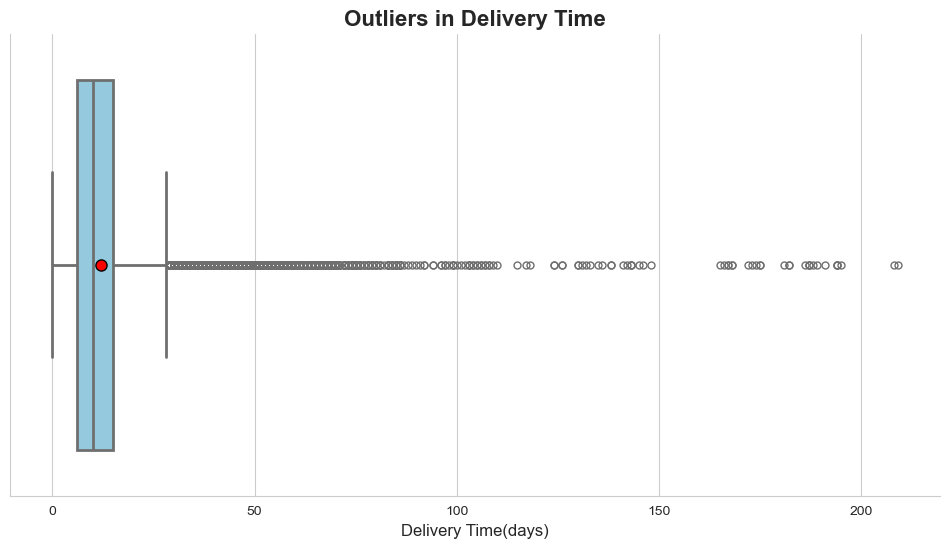

In [42]:
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
sns.boxplot(x=df['delivery_time'],
            color='skyblue',
            showmeans=True,
            meanprops = {"marker":"o","markerfacecolor" : "red","markeredgecolor" : "black","markersize" : "8"},
           fliersize=5,
           linewidth=2
           )
plt.title("Outliers in Delivery Time",fontsize=16,fontweight='bold')
plt.xlabel("Delivery Time(days)",fontsize=12)
sns.despine()
plt.show()

The boxplot illustrates the distribution of delivery time. The majority of orders are delivered within a short time range, as shown by the compact interquartile range (IQR).

The presence of numerous outliers on the higher end indicates that some orders experienced significantly longer delivery times. The mean being slightly higher than the median suggests a right-skewed distribution.

These outliers represent real-world delays in logistics and are important for analyzing delivery performance.

### IQR(Interquartile Range) Method for Outlier Detection (Delivery Time)

In [43]:
Q1 = df['delivery_time'].quantile(0.25)
Q3 = df['delivery_time'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_dt = df[(df['delivery_time'] < lower) | (df['delivery_time'] > upper)]
outliers_dt.shape

(5560, 26)

### IQR Method for Outlier Detection (Delivery Time)

The Interquartile Range (IQR) method is used to identify outliers in the delivery_time feature.

- Q1 (25th percentile) represents the lower quartile of the data.
- Q3 (75th percentile) represents the upper quartile.
- IQR is calculated as the difference between Q3 and Q1.

Outlier boundaries are defined as:
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Any values outside this range are considered outliers.

This method helps in detecting extreme delivery times that may affect analysis and model performance.

Using the IQR method, approximately 5,560 records were identified as outliers in delivery time. 
These represent unusually high or low delivery durations.

Since these values may reflect real-world logistics delays, they were retained for further analysis 
instead of being removed.

### Outlier Detection: Total Order Value

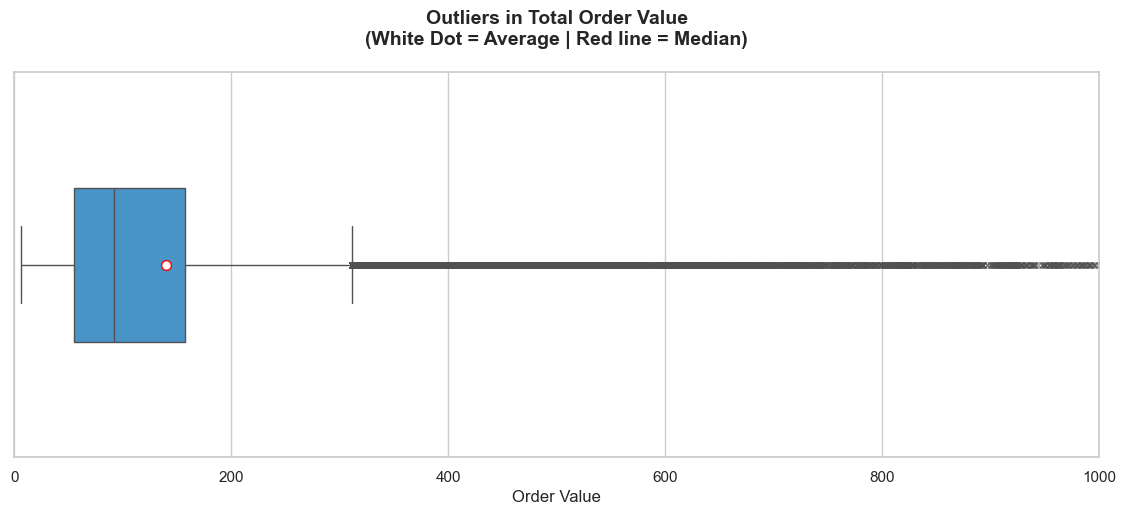

In [44]:
plt.figure(figsize=(14,5))
sns.set_theme(style="whitegrid")
sns.boxplot(x=df['total_order_value'],
           color='#3498db',
           width=0.4,
           showmeans=True,
           meanprops={
               "marker":"o",
               "markerfacecolor":"white",
               "markeredgecolor": "red",
               "markersize":"7"
           },
           flierprops={
               "marker":"x",
               "markersize":4,
               "alpha":0.5
           })
plt.title("Outliers in Total Order Value\n(White Dot = Average | Red line = Median)",fontsize=14,pad=20,fontweight='bold')
plt.xlabel("Order Value",fontsize=12)
plt.xlim(0, 1000)
plt.show()

The boxplot of total order value shows a highly right-skewed distribution. 
Most orders have relatively low values, while a small number of orders have significantly higher values, 
resulting in many outliers.

The mean is higher than the median, indicating the presence of high-value transactions that influence the average. 
These outliers represent real customer purchasing behavior and are important for revenue analysis.

### IQR Method for Outlier Detection (Total Order Value)

In [45]:
Q1_val = df['total_order_value'].quantile(0.25)
Q3_val = df['total_order_value'].quantile(0.75)
IQR_val = Q3_val - Q1_val

lower_val = Q1_val - 1.5 * IQR_val
upper_val = Q3_val + 1.5 * IQR_val

outliers_value = df[(df['total_order_value'] < lower_val) | (df['total_order_value'] > upper_val)]
outliers_value.shape

(8002, 26)

Using the IQR method, approximately 8,002 records were identified as outliers in total order value. 
These represent unusually high-value transactions.

The distribution of order value is highly right-skewed, with most orders having low values 
and a few orders contributing significantly higher amounts. These outliers are retained 
as they represent important customer behavior and are crucial for revenue analysis.

### Outlier Detection: Shipping Cost :

Outlier detection was also performed on shipping cost as it may influence delivery performance 
and is relevant for machine learning modeling. Although not critical for EDA, it is useful 
for identifying extreme cost variations.

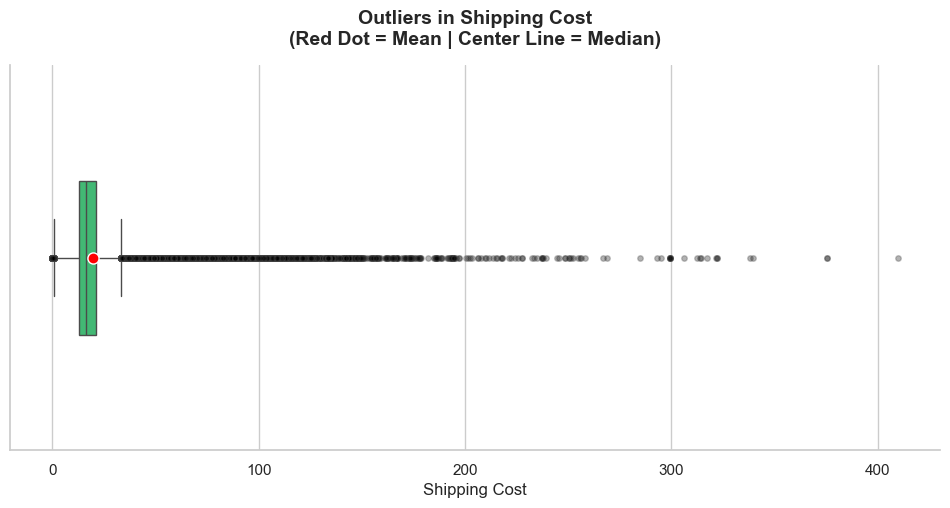

In [46]:
plt.figure(figsize=(12,5))
sns.set_theme(style="whitegrid")
sns.boxplot(x=df['shipping_cost'],
           color='#2ecc71',
           width=0.4,
           showmeans=True,
           meanprops={
               "marker":"o",
               "markerfacecolor":"red",
               "markeredgecolor": "white",
               "markersize":"8"
           },
           flierprops={
               "marker":"o",
               "markerfacecolor":"black",
               "markersize":4,
               "alpha":0.3
           })
plt.title("Outliers in Shipping Cost\n(Red Dot = Mean | Center Line = Median)",fontsize=14,fontweight='bold',pad=15)
plt.xlabel("Shipping Cost", fontsize=12)
sns.despine()
plt.show()

In [47]:
Q1_ship = df['shipping_cost'].quantile(0.25)
Q3_ship = df['shipping_cost'].quantile(0.75)
IQR_ship = Q3_ship - Q1_ship

lower_ship = Q1_ship - 1.5 * IQR_ship
upper_ship = Q3_ship + 1.5 * IQR_ship

outliers_ship = df[(df['shipping_cost'] < lower_ship) | (df['shipping_cost'] > upper_ship)]
outliers_ship.shape

(11812, 26)

Using the IQR method, approximately 11,812 records were identified as outliers in shipping cost. 
This represents a significant portion of the dataset, indicating high variability in shipping expenses.

The variation in shipping cost is expected, as it depends on factors such as distance, delivery location, 
and logistics complexity. These outliers were retained to preserve real-world cost variations, 
which are important for analysis and machine learning.

### Outlier Handling (Demonstration)

Outlier handling techniques such as capping were explored to limit extreme values. 
However, since the dataset represents real-world logistics and customer behavior, 
the original data was retained for analysis.

A separate capped dataset was created only for demonstration purposes, 
without modifying the original dataset used for EDA and visualization.

#### Copy the Original Dataset : 

In [48]:
df_capped = df.copy()

#### Outlier handling using capping method : 

In [49]:
# for delivery Time : 

df_capped['delivery_time'] = df_capped['delivery_time'].clip(lower, upper)

In [50]:
# for total order value : 
df_capped['total_order_value'] = df_capped['total_order_value'].clip(lower_val, upper_val)

#### Compare original outlier vs after handling outliers : 


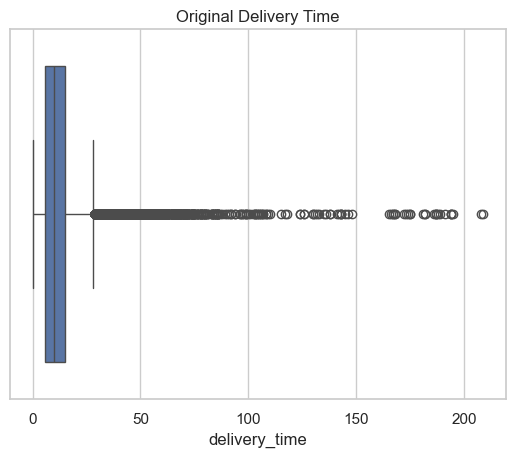

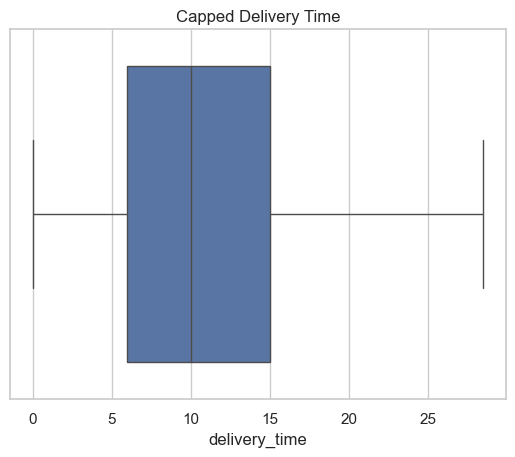

In [51]:
sns.boxplot(x=df['delivery_time'])
plt.title("Original Delivery Time")
plt.show()

sns.boxplot(x=df_capped['delivery_time'])
plt.title("Capped Delivery Time")
plt.show()

Outlier handling was demonstrated using capping techniques to limit extreme values. 
However, the original dataset was preserved to maintain real-world data integrity.

The capped dataset was not used for further analysis, ensuring that insights and 
visualizations reflect actual business scenarios.

--------------------------------------------------------------------------------------------------------------------

# Exploratory Data Analysis (EDA) and Visualization

Exploratory Data Analysis (EDA) is performed to identify patterns, trends, and relationships 
in the dataset. Visualization techniques are used to better understand delivery performance, 
order behavior, and regional distribution.

### Key Performance Indicators (KPI Summary) :

In [52]:
print("Total Orders:", len(df))
print("Average Delivery Time:", round(df['delivery_time'].mean(),2), "days")
print("Delay Percentage:", round(df['delay'].mean()*100,2), "%")
print("-"*100)

Total Orders: 110196
Average Delivery Time: 12.01 days
Delay Percentage: 7.91 %
----------------------------------------------------------------------------------------------------


### Monthly Order Volume Analysis

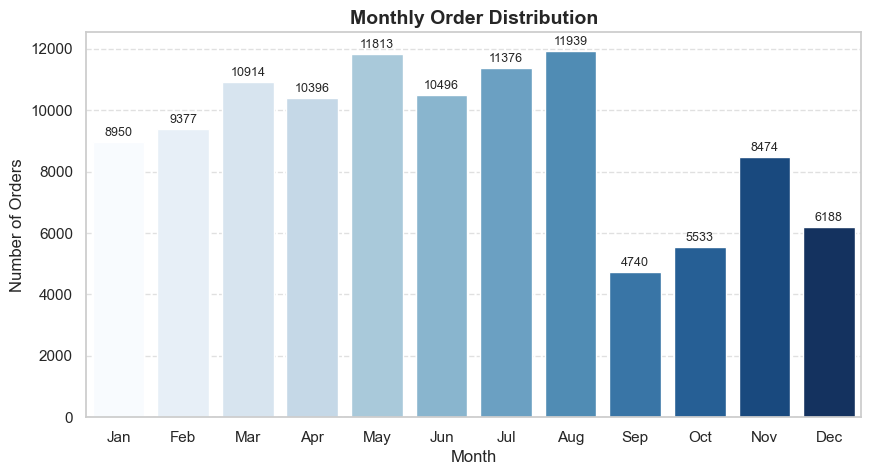

In [53]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='order_month',
    hue='order_month',   
    data=df,
    palette='Blues',
    legend=False
)

plt.title("Monthly Order Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Replace numbers with month names
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.xticks(ticks=range(12), labels=month_labels)

# Add values on bars
for p in plt.gca().patches:
    plt.text(
        p.get_x() + p.get_width()/2,
        p.get_height() + 200,
        int(p.get_height()),
        ha='center',
        fontsize=9
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [54]:
max_month = df['order_month'].value_counts().idxmax()
min_month = df['order_month'].value_counts().idxmin()

print(f"📈 Peak Order Month: {max_month}")
print(f"📉 Lowest Order Month: {min_month}")

📈 Peak Order Month: 8
📉 Lowest Order Month: 9


#### Monthly Order Distribution

This chart illustrates the distribution of orders across different months. 
It helps identify seasonal trends, peak demand periods, and fluctuations in customer activity.

The analysis shows that certain months experience higher order volumes, 
indicating increased customer demand, while other months show a noticeable decline. 
These variations may be influenced by seasonal factors, promotions, or external conditions.

Understanding these trends is important for demand forecasting, inventory planning, 
and optimizing logistics operations.

Peak order activity is observed around mid-year months, while a significant drop is seen in later months. 
This indicates possible seasonal demand patterns in the business.

### Distribution of Delivery Time :

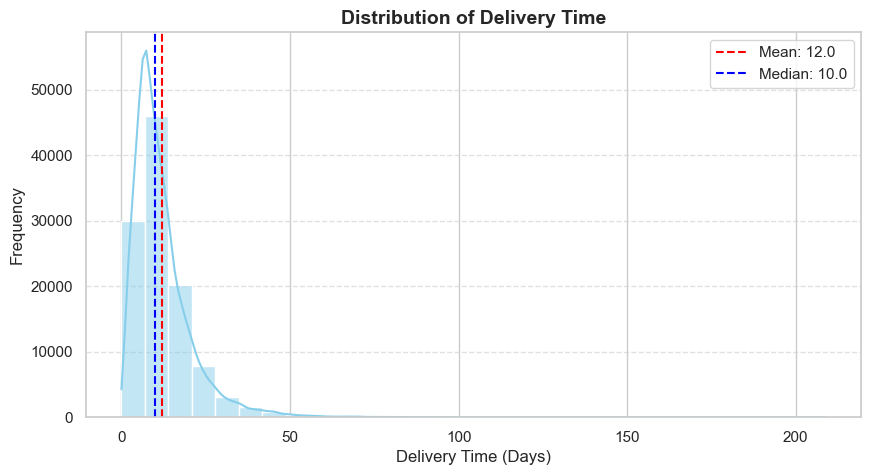

In [55]:
plt.figure(figsize=(10,5))

sns.histplot(df['delivery_time'], bins=30, kde=True, color='skyblue')

# Add mean & median lines
mean_val = df['delivery_time'].mean()
median_val = df['delivery_time'].median()

plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.1f}")
plt.axvline(median_val, color='blue', linestyle='--', label=f"Median: {median_val:.1f}")

plt.title("Distribution of Delivery Time", fontsize=14, fontweight='bold')
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [56]:
print(f"Average Delivery Time: {mean_val:.2f} days")
print(f"Median Delivery Time: {median_val:.2f} days")

Average Delivery Time: 12.01 days
Median Delivery Time: 10.00 days


#### Delivery Time Distribution

This histogram shows the distribution of delivery time across all orders. 
Most deliveries are completed within a short time range, while a few orders 
take significantly longer.

The distribution is right-skewed, indicating the presence of delayed deliveries. 
The mean delivery time is higher than the median, which confirms the influence 
of extreme values (outliers).

Understanding this distribution helps identify delivery efficiency and 
highlight potential logistics issues.

### Delivery Status Distribution (On-Time vs Delayed)

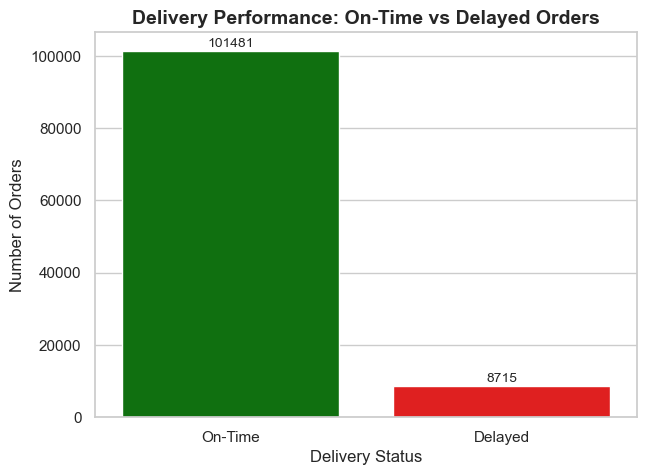

In [57]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='delay',
    hue='delay',   # fixes warning
    data=df,
    palette={0: 'green', 1: 'red'},
    legend=False
)

plt.title("Delivery Performance: On-Time vs Delayed Orders", fontsize=14, fontweight='bold')
plt.xlabel("Delivery Status", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Replace 0 and 1 with meaningful labels
plt.xticks(ticks=[0,1], labels=['On-Time', 'Delayed'])

# Add value labels on bars
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, 
             p.get_height() + 1000, 
             int(p.get_height()), 
             ha='center', fontsize=10)

plt.show()

#### Delivery Performance: On-Time vs Delayed Orders

This chart compares the number of on-time and delayed deliveries. 
Green bars represent on-time deliveries, while red bars indicate delayed orders.

The visualization shows that the majority of orders are delivered on time, 
indicating good overall logistics performance. However, a noticeable portion 
of delayed deliveries highlights areas for improvement in the supply chain.

### Delivery Time by Delivery Status (On-Time vs Delayed)

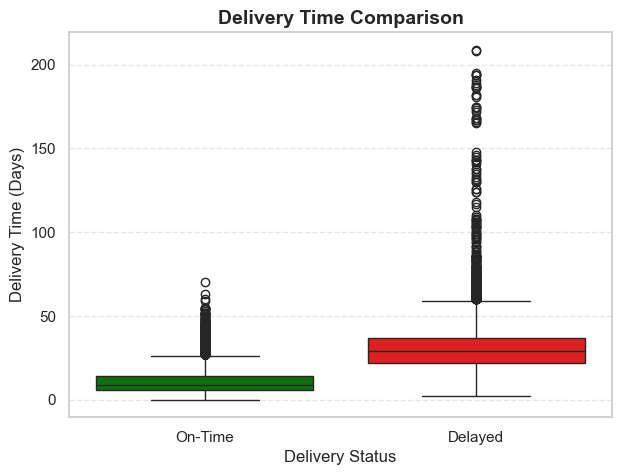

In [58]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='delay',
    y='delivery_time',
    data=df,
    hue='delay',             
    palette={0: 'green', 1: 'red'},
    legend=False                 # remove duplicate legend
)

plt.xticks([0,1], ['On-Time', 'Delayed'])
plt.title("Delivery Time Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Delivery Status")
plt.ylabel("Delivery Time (Days)")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Delivery Time Comparison (On-Time vs Delayed)

This boxplot compares delivery time between on-time and delayed orders.

The visualization clearly shows that delayed orders have significantly higher delivery times, 
with a wider spread and more extreme values.

This confirms that longer delivery duration is the primary factor contributing to delays, 
highlighting the importance of optimizing delivery time to improve overall logistics performance.

### Distribution of Delivery Speed Categories


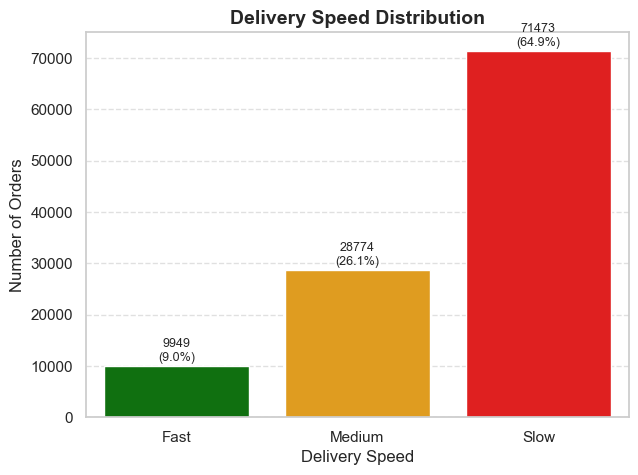

In [59]:
plt.figure(figsize=(7,5))

order = ['Fast', 'Medium', 'Slow']

sns.countplot(
    x='delivery_speed',
    hue='delivery_speed',   # fixes warning
    data=df,
    order=order,
    palette={'Fast':'green','Medium':'orange','Slow':'red'},
    legend=False
)

plt.title("Delivery Speed Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Delivery Speed", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Add values + percentage
total = len(df)
for p in plt.gca().patches:
    count = int(p.get_height())
    percent = f"{100 * count / total:.1f}%"
    
    plt.text(
        p.get_x() + p.get_width()/2,
        p.get_height() + 1000,
        f"{count}\n({percent})",
        ha='center',
        fontsize=9
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

A significant portion of deliveries are slow, suggesting that delivery performance 
can be improved by optimizing routes, reducing delays, and enhancing logistics efficiency.

In [60]:
df['delivery_speed'].value_counts()

delivery_speed
Slow      71473
Medium    28774
Fast       9949
Name: count, dtype: int64

#### Delivery Speed Distribution

This chart categorizes deliveries into fast, medium, and slow based on delivery time. 
It provides a clear overview of delivery performance.

The majority of orders fall under the "Slow" category, indicating potential inefficiencies 
in the logistics process. A smaller portion of orders are delivered quickly, while 
a moderate number fall in the medium range.

This distribution highlights the need to improve delivery speed and optimize logistics operations.

### Top Regions by Average Delivery Time

C:\Users\anand\AppData\Local\Temp\ipykernel_10972\202502965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


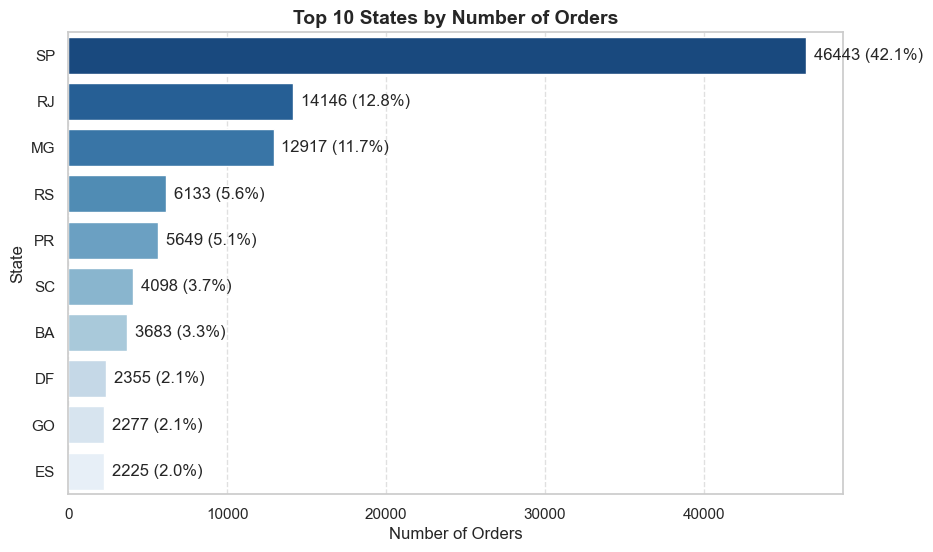

In [61]:
plt.figure(figsize=(10,6))

state_counts = df['state'].value_counts().head(10)

sns.barplot(
    x=state_counts.values,
    y=state_counts.index,
    palette='Blues_r'
)

plt.title("Top 10 States by Number of Orders", fontsize=14, fontweight='bold')
plt.xlabel("Number of Orders", fontsize=12)
plt.ylabel("State", fontsize=12)

# Add values + percentage
total = len(df)

for i, v in enumerate(state_counts.values):
    percent = f"{100 * v / total:.1f}%"
    plt.text(v + 500, i, f"{v} ({percent})", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

The dominance of a single state indicates regional concentration of demand, 
which may require focused logistics optimization and inventory management in that region.

In [62]:
top_state = df['state'].value_counts().idxmax()
print("Top State:", top_state)
print("\n")

Top State: SP




#### Top 10 States by Orders

This chart highlights the top 10 states based on the number of orders. 
It helps identify key regions contributing to overall business activity.

The analysis shows that one state (SP) dominates significantly, indicating a strong market presence. 
Other states such as RJ and MG also contribute but at a much lower scale.

This uneven distribution suggests that business demand is concentrated in specific regions, 
which can help in targeted logistics planning and resource allocation.

### Distribution of Shipping Cost

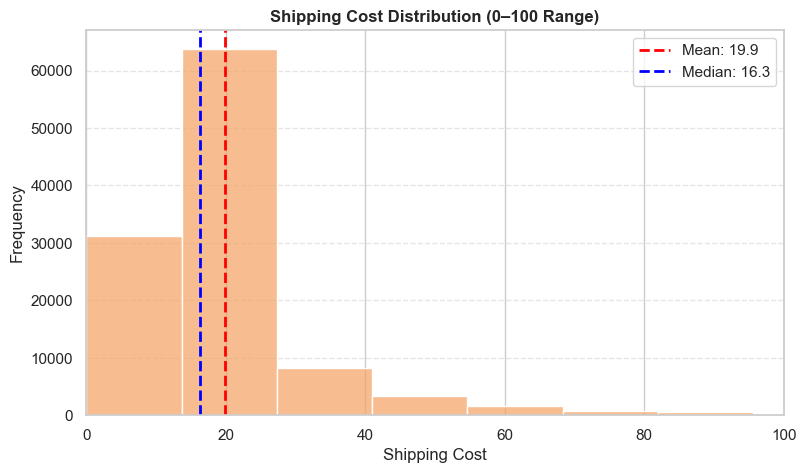

In [63]:
plt.figure(figsize=(9,5))

sns.histplot(df['shipping_cost'], bins=30, color='#f4a261', alpha=0.7)

mean_val = df['shipping_cost'].mean()
median_val = df['shipping_cost'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_val:.1f}")
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f"Median: {median_val:.1f}")

plt.title("Shipping Cost Distribution (0–100 Range)", fontweight='bold')
plt.xlabel("Shipping Cost")
plt.ylabel("Frequency")

plt.xlim(0, 100)  # 🔥 focused view

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

The focused view highlights that most shipping costs fall within the 0–100 range. 
This represents the majority of deliveries and provides a clear understanding of typical logistics costs.

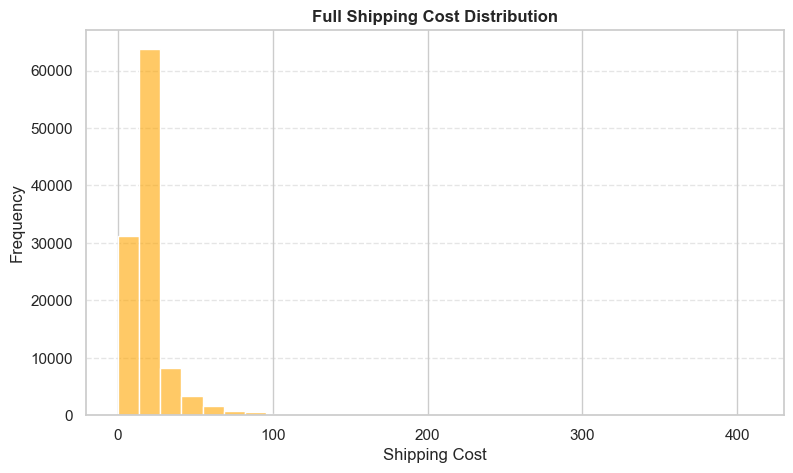

In [64]:
plt.figure(figsize=(9,5))

sns.histplot(df['shipping_cost'], bins=30, color='orange', alpha=0.6)

plt.title("Full Shipping Cost Distribution", fontweight='bold')
plt.xlabel("Shipping Cost")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

The full distribution reveals a long right tail, indicating the presence of high-cost outliers. 
These values represent deliveries involving long distances or complex logistics.

In [65]:
print(f"Average Shipping Cost: {mean_val:.2f}")
print(f"Median Shipping Cost: {median_val:.2f}")

Average Shipping Cost: 19.95
Median Shipping Cost: 16.26


#### Shipping Cost Distribution

The shipping cost distribution is highly right-skewed. While most deliveries incur low costs, 
a small number of orders have significantly higher shipping expenses. 

This suggests variability in logistics operations, likely influenced by distance, delivery location, 
and product characteristics.

### Feature Correlation Analysis

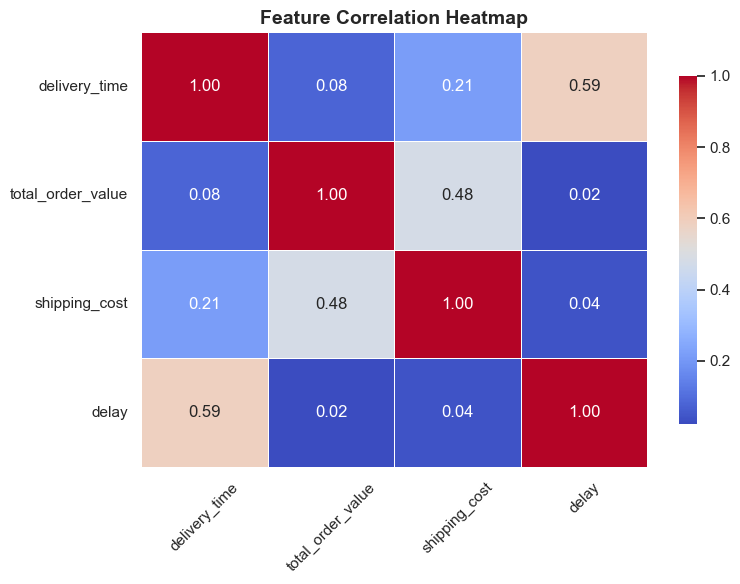

In [66]:
plt.figure(figsize=(8,6))

corr = df[['delivery_time','total_order_value','shipping_cost','delay']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Delivery time is the most significant factor affecting delays, making it a critical feature 
for predictive modeling and logistics optimization.

#### Feature Correlation Heatmap

The heatmap shows relationships between key numerical features using correlation values.

A strong positive correlation (0.59) is observed between delivery time and delay, 
indicating that longer delivery durations lead to higher chances of delayed orders.

A moderate relationship (0.48) exists between total order value and shipping cost, 
suggesting that higher-value orders tend to incur higher shipping expenses.

Other variables show weak or negligible correlations, indicating limited direct influence 
on delivery performance.

This analysis highlights delivery time as the most important factor affecting delays.

### Relationship between Delivery Time and Order Value

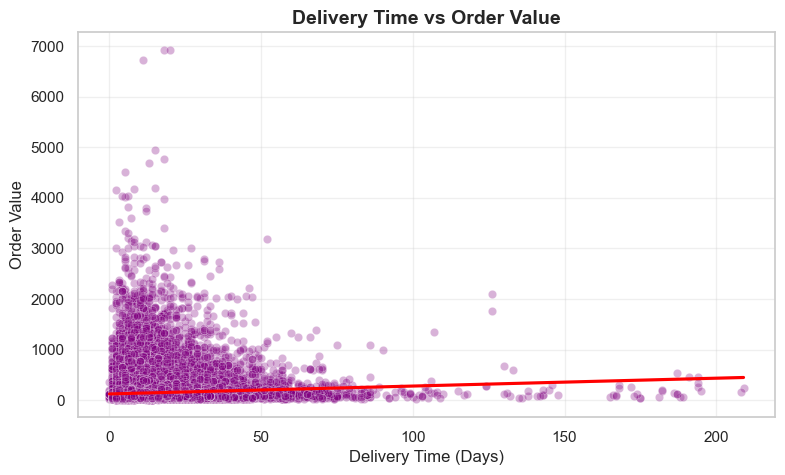

In [67]:
plt.figure(figsize=(9,5))

sns.scatterplot(
    x='delivery_time',
    y='total_order_value',
    data=df,
    alpha=0.3,
    color='purple'
)

# Add trend line 🔥
sns.regplot(
    x='delivery_time',
    y='total_order_value',
    data=df,
    scatter=False,
    color='red'
)

plt.title("Delivery Time vs Order Value", fontsize=14, fontweight='bold')
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Order Value", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

The lack of a strong relationship between order value and delivery time suggests that 
high-value orders are not prioritized differently in the logistics process.

#### Delivery Time vs Order Value

This scatter plot examines the relationship between delivery time and total order value. 
Each point represents an individual order.

The data shows a dense concentration of orders at lower delivery times and lower order values. 
There is no clear linear relationship between the two variables, as confirmed by the nearly flat trend line.

This indicates that order value does not significantly impact delivery time, 
suggesting that logistics performance is independent of order size.

### Relationship between Delivery Time and Order Value

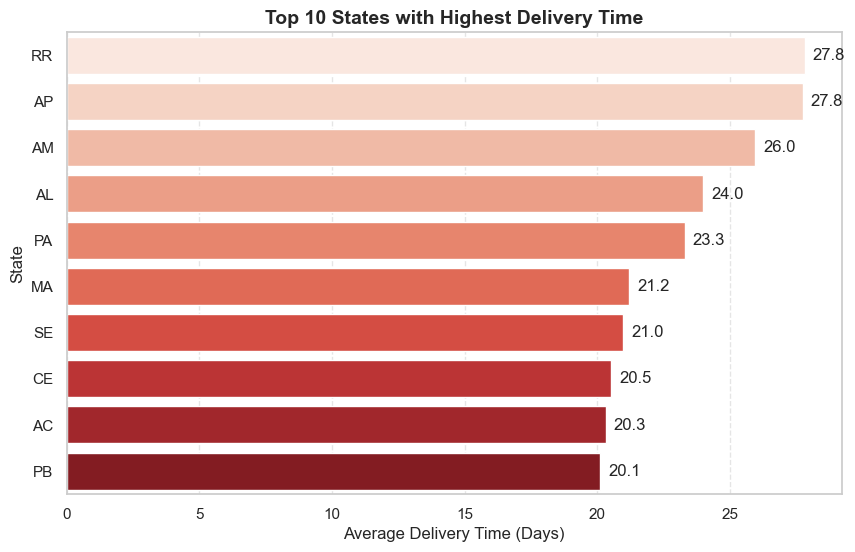

In [68]:
plt.figure(figsize=(10,6))

state_delivery = df.groupby('state')['delivery_time'].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=state_delivery.values,
    y=state_delivery.index,
    hue=state_delivery.index,   # fixes warning
    palette='Reds',
    legend=False
)

plt.title("Top 10 States with Highest Delivery Time", fontsize=14, fontweight='bold')
plt.xlabel("Average Delivery Time (Days)", fontsize=12)
plt.ylabel("State", fontsize=12)

# Add values
for i, v in enumerate(state_delivery.values):
    plt.text(v + 0.3, i, f"{v:.1f}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

States with the highest delivery times may represent regions with logistical inefficiencies, 
making them key targets for supply chain optimization.

In [69]:
worst_state = state_delivery.idxmax()
print("Highest Delivery Time State:", worst_state)
print("-"*50)

Highest Delivery Time State: RR
--------------------------------------------------


#### Top Regions by Delivery Time

This chart shows the top 10 states with the highest average delivery time. 
It helps identify regions where deliveries take longer than usual.

The analysis reveals that certain states consistently experience higher delivery times, 
indicating possible logistical challenges such as remote locations, longer distances, 
or infrastructure limitations.

These regions may require targeted improvements in route planning, warehouse placement, 
and delivery operations to enhance efficiency.

### Monthly Delay Analysis (On-Time vs Delayed Orders)

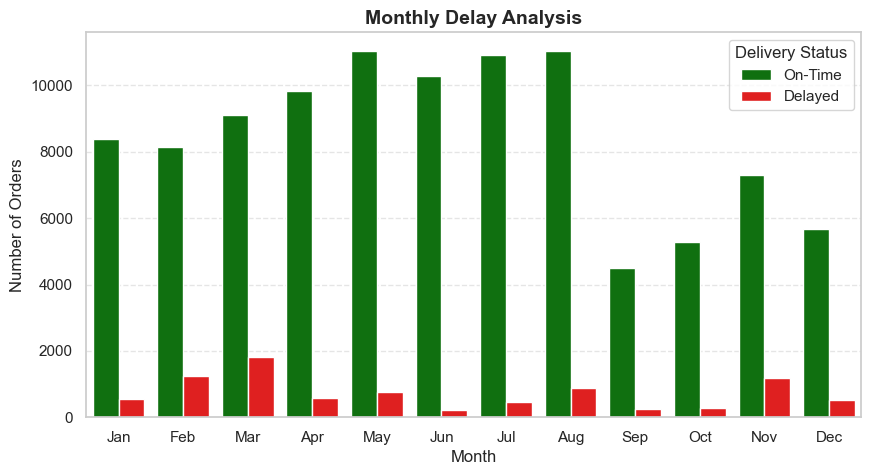

In [70]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='order_month',
    hue='delay',
    data=df,
    palette={0: 'green', 1: 'red'}
)

plt.title("Monthly Delay Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Month names
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.xticks(ticks=range(12), labels=month_labels)

# Replace legend labels
plt.legend(title='Delivery Status', labels=['On-Time', 'Delayed'])

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Monthly variations in delay patterns suggest that logistics performance is influenced by 
seasonal demand and operational factors.

#### Monthly Delay Analysis

This chart compares on-time and delayed deliveries across different months. 
Green bars represent on-time deliveries, while red bars indicate delayed orders.

The analysis shows that delays vary across months, suggesting the presence of seasonal 
patterns in logistics performance.

Certain months exhibit a higher number of delays, indicating potential operational challenges 
such as increased demand or logistical inefficiencies.

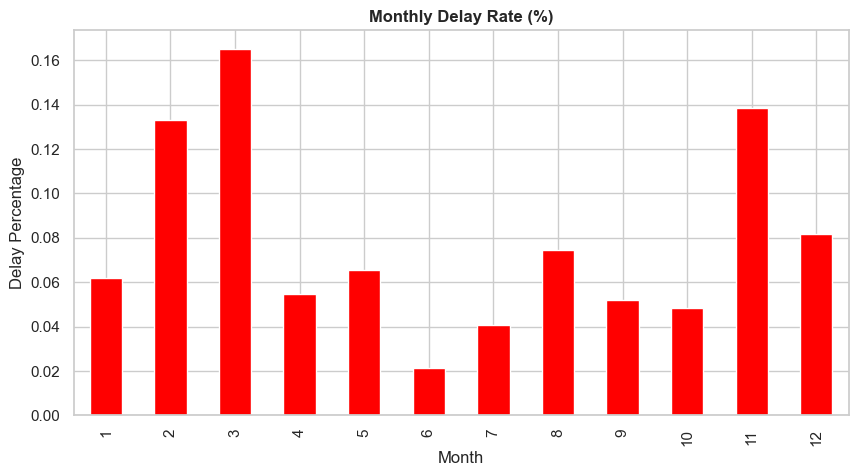

In [71]:
delay_rate = df.groupby('order_month')['delay'].mean()

plt.figure(figsize=(10,5))
delay_rate.plot(kind='bar', color='red')

plt.title("Monthly Delay Rate (%)", fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Delay Percentage")

plt.show()

#### Monthly Delay Rate (%)

This chart shows the percentage of delayed orders across different months. 
Unlike the count-based chart, this provides a clearer understanding of delivery performance.

Some months may have fewer total orders but a higher delay rate, indicating 
potential inefficiencies in logistics operations.

While some months have higher order volumes, the delay percentage reveals actual 
performance issues. Months with higher delay rates require focused logistics improvements.

### Distribution of Order Value

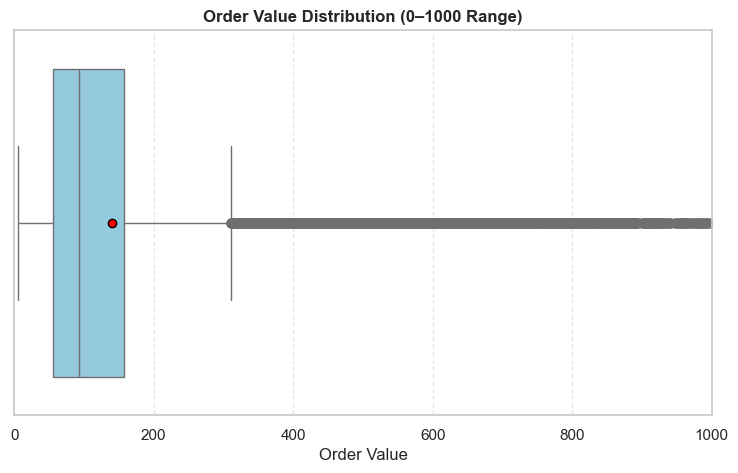

In [72]:
plt.figure(figsize=(9,5))

sns.boxplot(
    x=df['total_order_value'],
    color='skyblue',
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"red","markeredgecolor":"black"}
)

plt.title("Order Value Distribution (0–1000 Range)", fontweight='bold')
plt.xlabel("Order Value")

plt.xlim(0, 1000)  # 🔥 Focus on main data

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

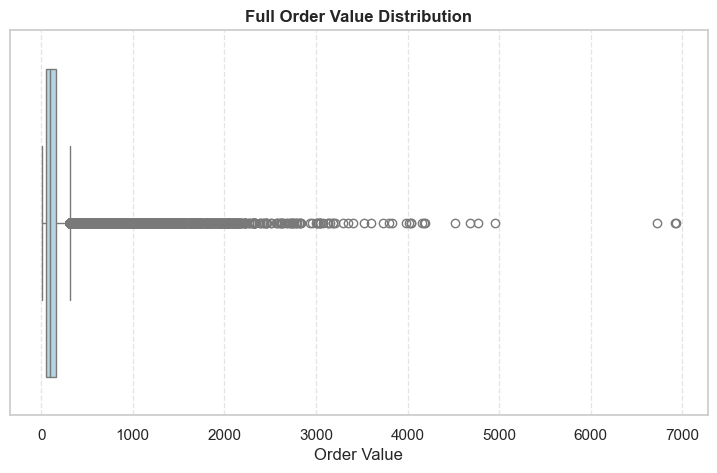

In [73]:
plt.figure(figsize=(9,5))

sns.boxplot(
    x=df['total_order_value'],
    color='lightblue'
)

plt.title("Full Order Value Distribution", fontweight='bold')
plt.xlabel("Order Value")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

In [74]:
print("Max Order Value:", df['total_order_value'].max())
print("Average Order Value:", df['total_order_value'].mean())
print("-"*50)

Max Order Value: 6929.31
Average Order Value: 139.9247106065556
--------------------------------------------------


#### Order Value Distribution

The boxplot shows the distribution of total order values. 
Most orders fall within a lower price range, while a few high-value orders 
create significant outliers.

A focused view (0–1000) highlights the main distribution, showing that the majority 
of transactions are low-value purchases.

The full distribution reveals a long right tail, indicating the presence of 
high-value orders that contribute significantly to overall revenue.

The presence of high-value outliers suggests that a small number of orders contribute 
disproportionately to total revenue, which is important for business strategy.

### Regional and Monthly Delay Pattern Analysis

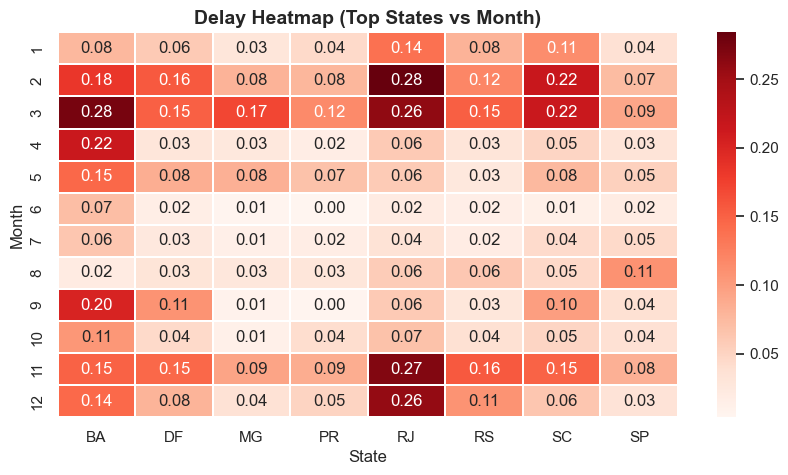

In [75]:
top_states = df['state'].value_counts().head(8).index

pivot = pd.pivot_table(
    df[df['state'].isin(top_states)],
    values='delay',
    index='order_month',
    columns='state',
    aggfunc='mean'
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    cmap='Reds',
    annot=True,
    fmt=".2f",
    linewidths=0.3
)

plt.title("Delay Heatmap (Top States vs Month)", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Month")

plt.show()

#### Delay Heatmap (Region vs Time)

This heatmap represents the delay rate across different months and states. 
Each cell shows the percentage of delayed orders, with darker shades indicating higher delay frequency.

The analysis reveals that delays are not uniform across time and regions. 
Certain months, particularly early and late in the year, show higher delay rates, 
suggesting seasonal demand or operational challenges.

Some states, such as RJ and BA, consistently exhibit higher delay rates, 
indicating potential regional inefficiencies in logistics.

In contrast, mid-year months show relatively lower delays, suggesting improved delivery performance.

This visualization helps identify both temporal and regional patterns in delivery delays, 
which can be used to improve logistics planning and operational efficiency.

Certain states show consistently higher delay rates during specific months, 
indicating potential seasonal or regional logistics inefficiencies.

------------------------------------------------------------------------------------------------------------------

### Key Insights from Exploratory Data Analysis

1. **Delivery Time as the Key Factor**
   - Delivery time shows a strong relationship with delay.
   - Orders with longer delivery durations are significantly more likely to be delayed.
   - This makes delivery time the most critical factor affecting logistics performance.

2. **Overall Delivery Performance**
   - The majority of orders are delivered on time, indicating a generally efficient logistics system.
   - However, a noticeable portion of delayed deliveries highlights areas for improvement.

3. **Regional Performance Variation**
   - Certain states consistently experience higher delivery times and delays.
   - This suggests regional inefficiencies, possibly due to distance, infrastructure, or logistics constraints.
   - Demand is heavily concentrated in a few key regions.

4. **Seasonal Patterns in Delays**
   - Delay patterns vary across months, with some months showing higher delay rates.
   - This indicates the presence of seasonal demand or operational challenges affecting delivery performance.

5. **Order Value and Shipping Cost Behavior**
   - Most orders are low-value, while a small number of high-value orders contribute significantly to total revenue.
   - Shipping cost is positively related to order value, suggesting higher-value orders may involve higher logistics costs.

6. **Skewed Distributions**
   - Delivery time, order value, and shipping cost all exhibit right-skewed distributions.
   - A small number of extreme values (outliers) represent delayed deliveries or high-cost transactions.

7. **Weak Relationship Between Order Value and Delivery Time**
   - There is no strong relationship between order value and delivery time.
   - This suggests that high-value orders are not prioritized differently in delivery operations.

8. **Delivery Speed Distribution**
   - A significant portion of deliveries falls under slower categories, indicating potential inefficiencies.
   - Improving delivery speed can directly enhance customer satisfaction and operational performance.

9. **Correlation Analysis**
   - Delivery time has the strongest correlation with delay.
   - Other variables such as shipping cost and order value show moderate or weak relationships.
   - This highlights delivery time as the most important feature for predictive modeling.

10. **Advanced Regional and Temporal Patterns**
    - The heatmap analysis reveals that certain states experience higher delays during specific months.
    - This indicates combined regional and seasonal effects on logistics performance.

--------------------------------------------------------------------------------------------------------

## Data Cleaning Summary

- Missing values were handled and unnecessary columns were removed
- Date columns were converted into proper datetime format
- New features such as delivery_time, delay indicator, and delivery speed category were created
- Data types were corrected to ensure consistency and accuracy

## Key Observations

- The majority of orders are delivered on time, indicating overall efficient logistics operations
- A noticeable percentage of delayed orders highlights areas for improvement
- Delivery time varies significantly, with some extreme delays observed
- Certain states contribute more to total orders and revenue
- Monthly trends show fluctuations in demand and delivery performance

## KPI Summary

- Total Orders: High transaction volume observed across the dataset
- Total Revenue: Strong revenue generation from product sales
- Average Delivery Time: Moderate delivery efficiency with room for optimization
- Delay Percentage: Indicates operational inefficiencies in certain cases

## Insights from Visualizations

- Delayed orders are associated with longer delivery times
- Peak demand periods tend to experience higher delays
- Some regions consistently show higher delivery times and delays
- Shipping cost does not guarantee faster delivery, indicating inefficiencies

## Transition to SQL Analysis

After completing data cleaning and exploratory data analysis using Pandas, 
the cleaned dataset is exported and loaded into MySQL.

SQL is then used to perform structured KPI analysis and create views 
for efficient dashboard development in Power BI.

--------------------------------------------------------------------------------------------------------------------------

## Saving Cleaned Dataset

After completing data cleaning, feature engineering, and exploratory data analysis, 
the final processed dataset is saved as a CSV file.

This step ensures that the cleaned data can be reused for further analysis in SQL, 
Power BI dashboards, and machine learning models without repeating preprocessing steps.

Saving the dataset also improves workflow efficiency and maintains consistency across different stages of the project.

In [76]:
df.to_csv("../data/cleaned_supply_chain_data.csv", index=False)
df.shape

(110196, 26)

The dataset includes key engineered features such as delivery time, delay indicator, 
delivery speed category, order month, shipping cost, and total order value, 
making it ready for advanced analysis and modeling.

---------------------------------------------------------------------------------------------------------------------------

## Conclusion : 

This project analyzed supply chain and logistics performance using the Olist e-commerce dataset. 
Through data cleaning, feature engineering, and exploratory data analysis, several key insights were identified.

Delivery time emerged as the most critical factor influencing delays, with longer delivery durations 
significantly increasing the likelihood of late deliveries. Regional analysis revealed that certain states 
consistently experience higher delivery times, indicating potential logistical challenges.

Seasonal patterns in delays were also observed, suggesting that demand fluctuations and operational factors 
impact delivery performance across different months. Additionally, most orders were found to be low-value, 
with a small number of high-value transactions contributing significantly to overall revenue.

The analysis highlights the importance of optimizing delivery time, improving performance in high-delay regions, 
and enhancing logistics planning to reduce delays. These insights can support data-driven decision-making 
and improve overall supply chain efficiency.

Overall, the findings from this analysis provide a strong foundation for further KPI analysis, 
dashboard visualization, and predictive modeling in subsequent stages of the project.

### SQL Query File

All SQL queries used for KPI analysis are stored in a separate `.sql` file. 
This helps maintain clean organization and allows easy execution of queries 
in MySQL Workbench.

-------------------------------------------------------------------------------------------------------------------------

## Machine Learning: Delivery Time Prediction

### Problem Statement

The objective is to build a machine learning model to predict delivery time 
based on order and logistics features such as product price, shipping cost, 
region, and order characteristics.

This helps improve delivery planning and logistics efficiency.

### Features Used

- product_price → Order value  
- shipping_cost → Logistics cost  
- state → Delivery region  
- order_weekday → Order day  

### Target Variable

- delivery_time → Time taken to deliver the order

### import libraries 

In [77]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

### Load Dataset

In [78]:
df = pd.read_csv("../data/cleaned_supply_chain_data.csv")
df.head()

,order_id,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_price,shipping_cost,delivery_time,delay,order_month,order_weekday,delay_days,delay_category,total_order_value,delivery_speed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,8,0,10,Monday,-8,On Time,38.71,Slow
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,13,0,7,Tuesday,-6,On Time,141.46,Slow
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,9,0,8,Wednesday,-18,On Time,179.12,Slow
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,13,0,11,Saturday,-13,On Time,72.20,Slow
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,2,0,2,Tuesday,-10,On Time,28.62,Fast


### Feature Engineering : 

In [79]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['order_month'] = df['order_date'].dt.month
df['order_weekday'] = df['order_date'].dt.weekday

df['order_value_category'] = pd.cut(
    df['product_price'],
    bins=[0, 100, 500, 1000, 10000],
    labels=[0,1,2,3]
)
# Weekend feature
df['is_weekend'] = df['order_weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Price to shipping ratio (IMPORTANT)
df['price_shipping_ratio'] = df['product_price'] / df['shipping_cost'].replace(0,1)

### Feature Selection 

In [80]:
features = [
    'product_price',
    'shipping_cost',
    'order_month',
    'order_weekday',
    'price_shipping_ratio'
]
X = df[features]
y = df['delivery_time']

### Train - test Split Data : 

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train model : 

In [82]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Prediction 

In [83]:
y_pred = rf.predict(X_test)

### Model Evaluation 

In [84]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 5.028215494652502
R2 Score: 0.2539025803123619


### Cross Validation : 

In [85]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-Validation R2:", scores.mean())

Cross-Validation R2: 0.19364494224305767


### Feature Importance 

In [86]:

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

shipping_cost           0.394671
price_shipping_ratio    0.217504
product_price           0.170550
order_month             0.127692
order_weekday           0.089583
dtype: float64


### Sample Predition 

In [87]:
sample = pd.DataFrame([{
    'product_price': 500,
    'shipping_cost': 50,
    'order_month': 5,
    'order_weekday': 2,
    'price_shipping_ratio': 500/50
}])

prediction = rf.predict(sample)

print("Predicted Delivery Time:", round(prediction[0],2), "days")

Predicted Delivery Time: 13.73 days


### Save Model 

In [91]:
model = pickle.load(open("../models/delivery_model.pkl", "rb"))